In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("restaraunts_tallinn.csv")
df.head()

,Restaurant,URL,Address,Cuisine,Price_category,Atmosphere,Food,Service,Weighted_score,Latitude,Longitude
0,Al Mare Grill,http://www.almarefood.ee/grill/,Mõisa tn 4,american,mid-range,3.5,3.0,3.1,3.12,59.427152,24.655658
1,Allee,https://www.alleerestoran.ee/,Kanuti 2,international,mid-range,4.0,4.1,3.9,4.04,59.440128,24.751131
2,Argentiina Lootsi,https://argentiina.ee/,Lootsi 8,argentinean,expensive,3.3,4.3,3.6,3.96,59.440838,24.765225
3,Argentiina Pärnu mnt,https://argentiina.ee/,Pärnu mnt 37,argentinean,expensive,4.1,4.5,4.2,4.36,59.429272,24.743789
4,Charlies Corner,https://charliescorner.ee/,Juhkentali 28,international,mid-range,3.9,3.9,3.9,3.90,59.427606,24.764699


# Problem set for clustering and recommendation systems 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Restaurant      97 non-null     object 
 1   URL             94 non-null     object 
 2   Address         97 non-null     object 
 3   Cuisine         97 non-null     object 
 4   Price_category  97 non-null     object 
 5   Atmosphere      97 non-null     float64
 6   Food            97 non-null     float64
 7   Service         97 non-null     float64
 8   Weighted_score  97 non-null     float64
 9   Latitude        97 non-null     float64
 10  Longitude       97 non-null     float64
dtypes: float64(6), object(5)
memory usage: 8.5+ KB


In [4]:
df.isnull().sum()

Restaurant        0
URL               3
Address           0
Cuisine           0
Price_category    0
Atmosphere        0
Food              0
Service           0
Weighted_score    0
Latitude          0
Longitude         0
dtype: int64

Budget (0–10€): fast food, canteens, simple meals.
Mid-range (10–30€): casual dining, standard restaurants.
Expensive (30–60€): upscale casual, higher-quality dining.
Premium (60€+): fine dining and higher-end establishments.

In [5]:
df.Price_category.unique()

array(['mid-range', 'expensive', 'budget', 'premium'], dtype=object)

In [6]:
cat_col = df.select_dtypes(include='object').columns
num_col = df.select_dtypes(exclude='object').columns

In [7]:
cat_col

Index(['Restaurant', 'URL', 'Address', 'Cuisine', 'Price_category'], dtype='object')

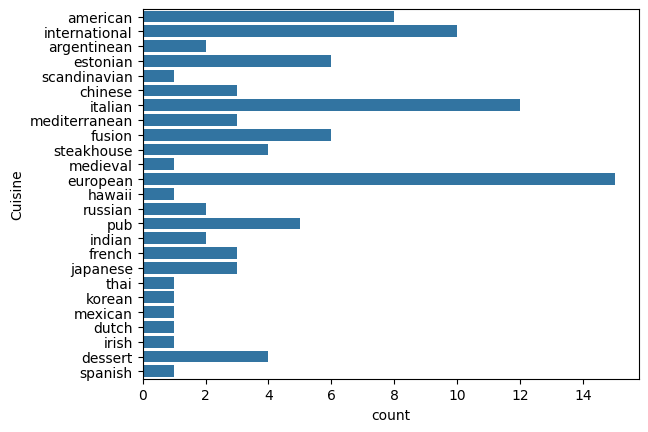

In [8]:
sns.countplot(df.Cuisine)
plt.show()

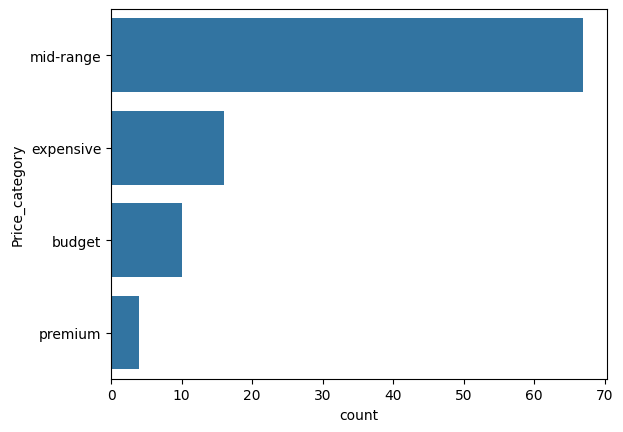

In [9]:
sns.countplot(df.Price_category)
plt.show()

In [10]:
num_col

Index(['Atmosphere', 'Food', 'Service', 'Weighted_score', 'Latitude',
       'Longitude'],
      dtype='object')

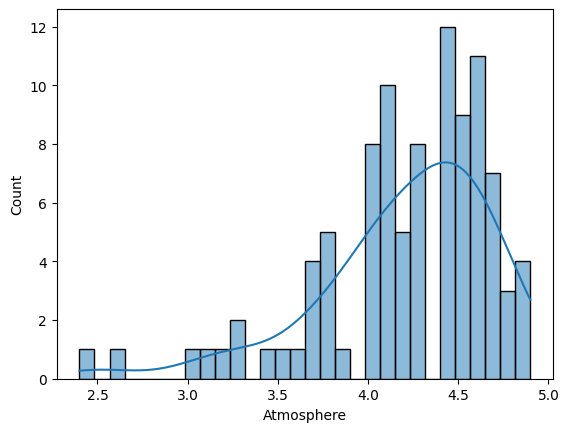

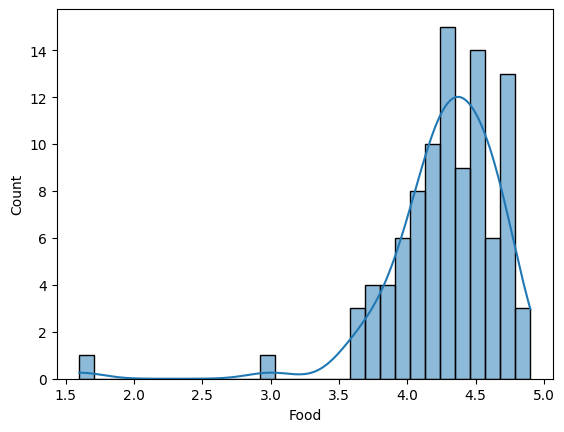

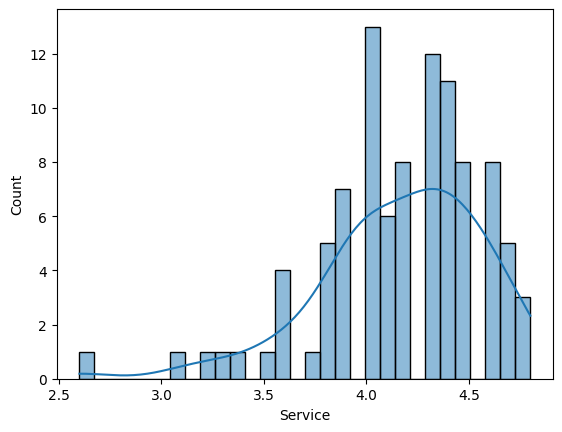

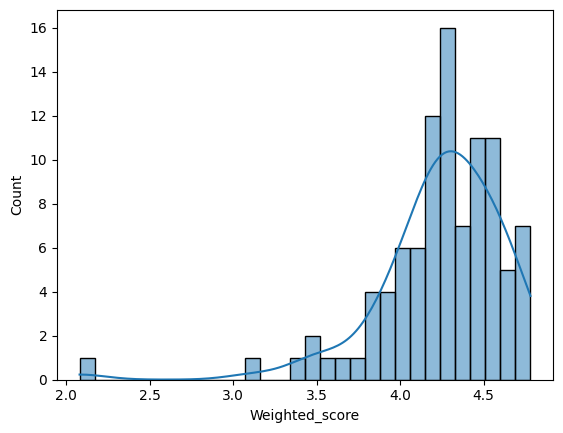

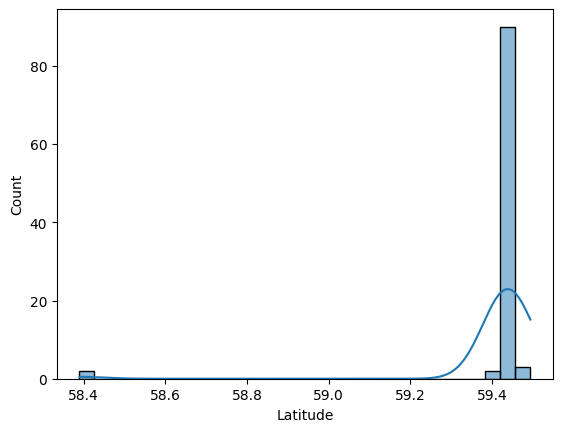

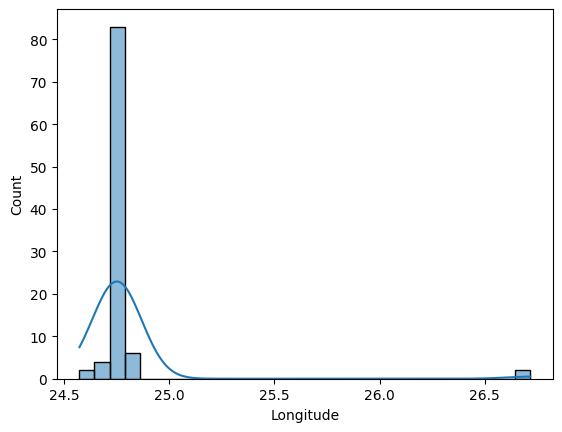

In [11]:
for i in num_col:
    sns.histplot(df[i], kde=True, bins=30)
    plt.show()

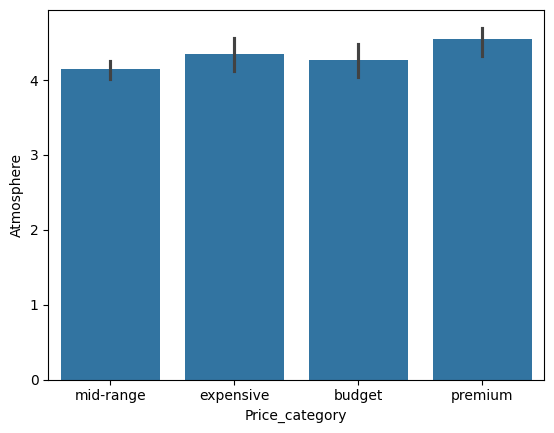

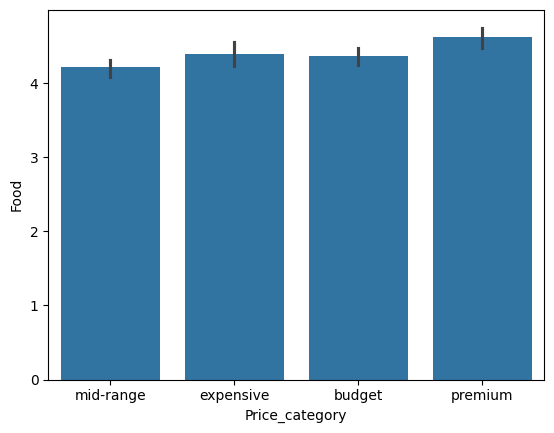

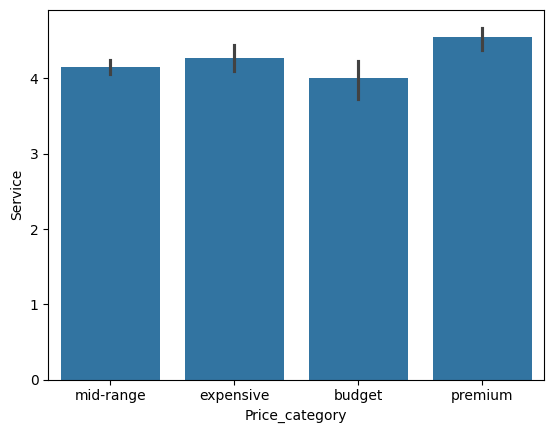

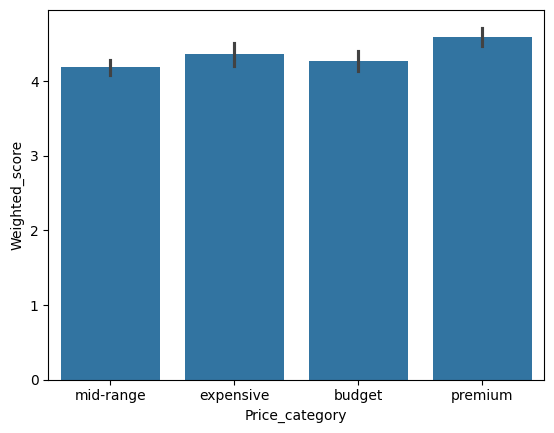

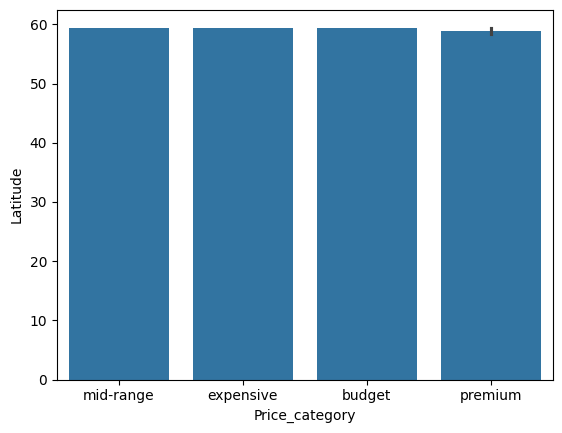

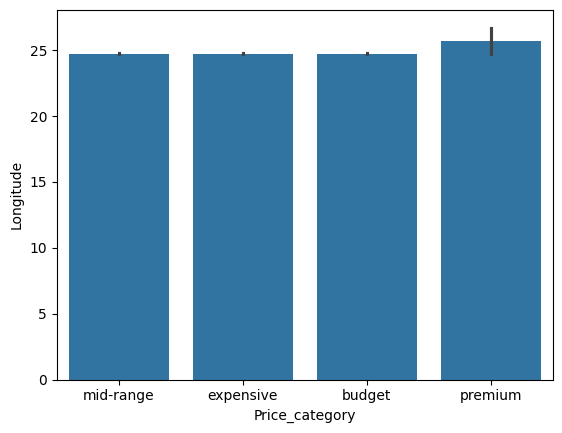

In [12]:
for i in num_col:
    sns.barplot(x=df.Price_category, y=df[i])
    plt.show()

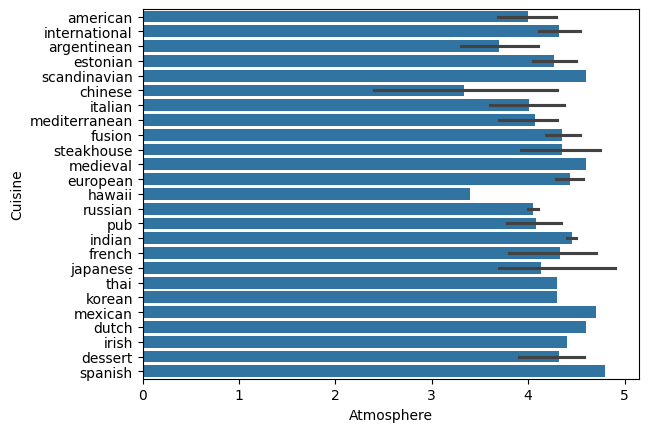

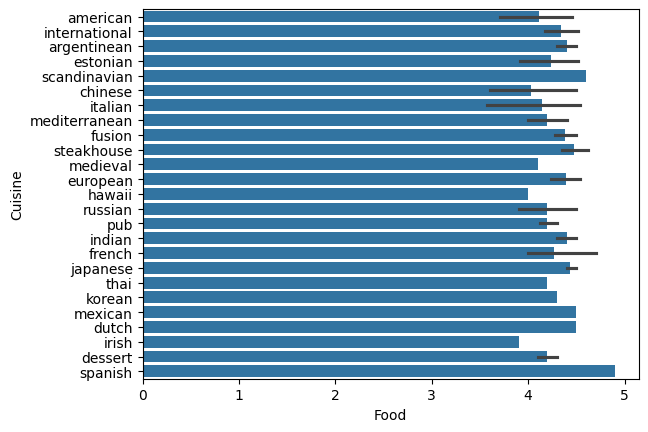

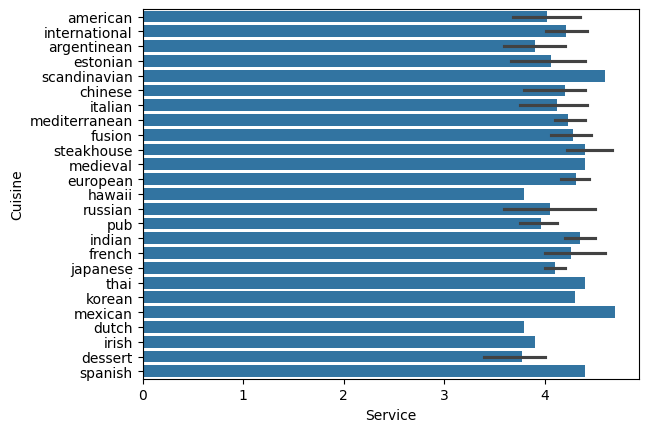

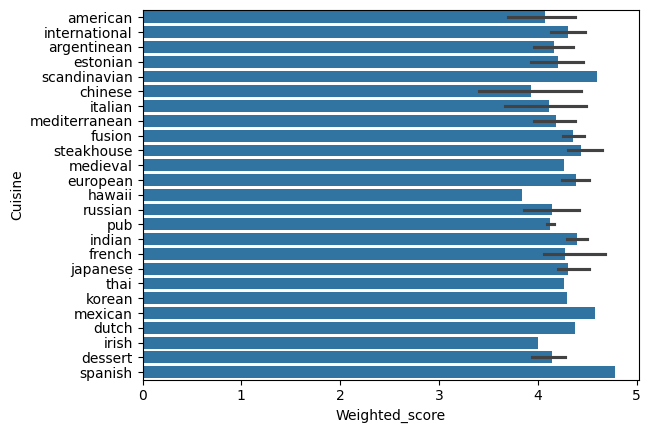

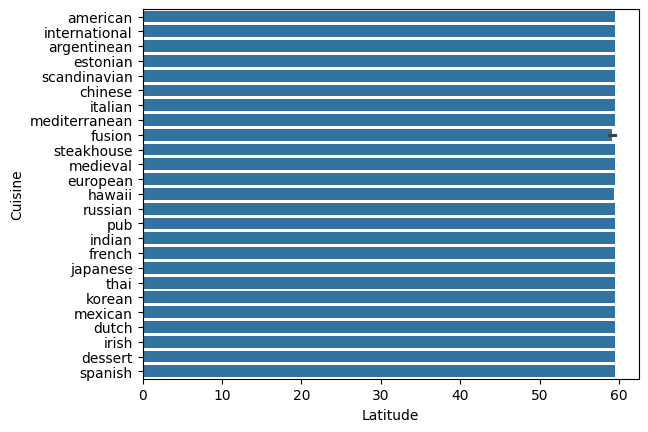

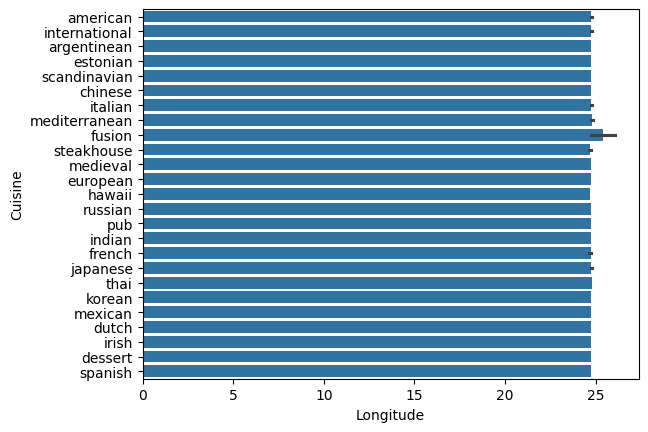

In [13]:
for i in num_col:
    sns.barplot(y=df.Cuisine, x=df[i])
    plt.show()

In [14]:
from sklearn.cluster import KMeans

In [15]:
df.columns

Index(['Restaurant', 'URL', 'Address', 'Cuisine', 'Price_category',
       'Atmosphere', 'Food', 'Service', 'Weighted_score', 'Latitude',
       'Longitude'],
      dtype='object')

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor  # or KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

In [17]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
label = LabelEncoder()
for i in cat_col:
    df[i] = label.fit_transform(df[i])
scale = StandardScaler()
x_scale = scale.fit_transform(df)

In [18]:
df.head()

,Restaurant,URL,Address,Cuisine,Price_category,Atmosphere,Food,Service,Weighted_score,Latitude,Longitude
0,1,7,28,0,2,3.5,3.0,3.1,3.12,59.427152,24.655658
1,2,86,14,11,2,4.0,4.1,3.9,4.04,59.440128,24.751131
2,4,38,24,1,1,3.3,4.3,3.6,3.96,59.440838,24.765225
3,5,38,44,1,1,4.1,4.5,4.2,4.36,59.429272,24.743789
4,13,44,11,11,2,3.9,3.9,3.9,3.90,59.427606,24.764699


In [19]:
X = df.drop('Weighted_score', axis=1)
y = df['Weighted_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train1 = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

In [20]:
model = KNeighborsRegressor(n_neighbors=4)
model.fit(X_train1, y_train)

,n_neighbors,4
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
pred = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
print("MSE", mean_squared_error(pred, y_test))
print('R2', r2_score(pred, y_test))

MSE 0.030429999999999978
R2 0.4181199326908367


In [23]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(x_scale)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [24]:
df['cluster'] = kmeans.labels_

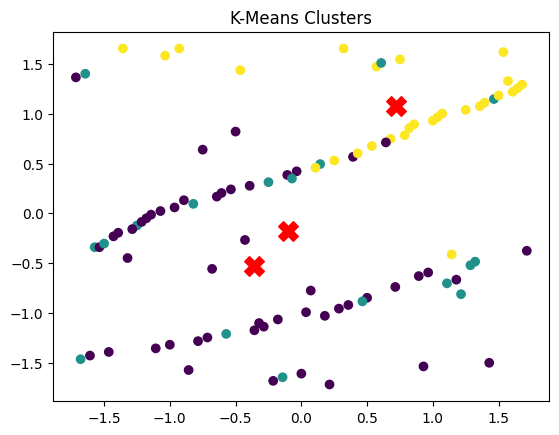

In [25]:
import matplotlib.pyplot as plt

plt.scatter(x_scale[:, 0], x_scale[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            color='red', marker='X', s=200)

plt.title("K-Means Clusters")
plt.show()